### SVM

**Машина опорных векторов (SVM)** - это алгоритм классификации, который разделяет объекты разных классов проводя между ними границу с максимальным отступом. Если данные нельзя разделить прямой линией, в SVM можно использовать ядра.

## Используемые библиотеки

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

## Используемый датасет

In [19]:
cancer = load_breast_cancer()

features = [
    ("mean radius", "Средний радиус клетки"),
    ("mean texture", "Средняя текстура"),
    ("mean perimeter", "Средний периметр клетки"),
    ("mean area", "Средняя площадь клетки"),
    ("mean smoothness", "Средняя гладкость"),
    ("mean compactness", "Средняя компактность"),
    ("mean concavity", "Средняя вогнутость"),
    ("mean concave points", "Среднее число вогнутых точек"),
    ("mean symmetry", "Средняя симметричность клетки"),
    ("mean fractal dimension", "Средняя фрактальная размерность"),

    ("radius error", "Ошибка измерения радиуса"),
    ("texture error", "Ошибка измерения текстуры"),
    ("perimeter error", "Ошибка измерения периметра"),
    ("area error", "Ошибка измерения площади"),
    ("smoothness error", "Ошибка измерения гладкости"),
    ("compactness error", "Ошибка измерения компактности"),
    ("concavity error", "Ошибка измерения вогнутости"),
    ("concave points error", "Ошибка подсчета вогнутых точек"),
    ("symmetry error", "Ошибка измерения симметрии"),
    ("fractal dimension error", "Ошибка фрактальной размерности"),

    ("worst radius", "Максимальный радиус клетки"),
    ("worst texture", "Максимальная текстура"),
    ("worst perimeter", "Максимальный периметр клетки"),
    ("worst area", "Максимальная площадь клетки"),
    ("worst smoothness", "Максимальная гладкость"),
    ("worst compactness", "Максимальная компактность"),
    ("worst concavity", "Максимальная вогнутость"),
    ("worst concave points", "Максимальное число вогнутых точек"),
    ("worst symmetry", "Максимальная симметрия"),
    ("worst fractal dimension", "Максимальная фрактальная размерность")
]
for i in range(10):
    name, desc = features[i]
    print(f"{i+1:2}. {name:25} - {desc:35}")

df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['diagnosis'] = df['target'].apply(lambda x: cancer.target_names[x])

print(f"\n Размер датасета: {df.shape[0]} образцов, {df.shape[1]-2} признаков")
print(f" Признаков: {len(cancer.feature_names)} (характеристики ядер клеток)")
print(f" Классы: {list(cancer.target_names)}")
print(f" {cancer.target_names[0]}: {sum(df['target']==0)} образцов (доброкачественные)")
print(f" {cancer.target_names[1]}: {sum(df['target']==1)} образцов (злокачественные)")

print("\n Первые 5 строк:")
print(df.head())

print("\n Статистика по признакам:")
print(df[cancer.feature_names[:5]].describe())

print("\n Проверка на пропуски:")
print(df.isnull().sum().sum(), "пропусков в данных")

 1. mean radius               - Средний радиус клетки              
 2. mean texture              - Средняя текстура                   
 3. mean perimeter            - Средний периметр клетки            
 4. mean area                 - Средняя площадь клетки             
 5. mean smoothness           - Средняя гладкость                  
 6. mean compactness          - Средняя компактность               
 7. mean concavity            - Средняя вогнутость                 
 8. mean concave points       - Среднее число вогнутых точек       
 9. mean symmetry             - Средняя симметричность клетки      
10. mean fractal dimension    - Средняя фрактальная размерность    

 Размер датасета: 569 образцов, 30 признаков
 Признаков: 30 (характеристики ядер клеток)
 Классы: [np.str_('malignant'), np.str_('benign')]
 malignant: 212 образцов (доброкачественные)
 benign: 357 образцов (злокачественные)

 Первые 5 строк:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \


## Обработка датасета

In [20]:
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")
print(f"Соотношение классов в обучающей: {np.bincount(y_train)}")
print(f"Соотношение классов в тестовой: {np.bincount(y_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Обучающая выборка: 398 образцов
Тестовая выборка: 171 образцов
Соотношение классов в обучающей: [148 250]
Соотношение классов в тестовой: [ 64 107]


## Тепловая карта

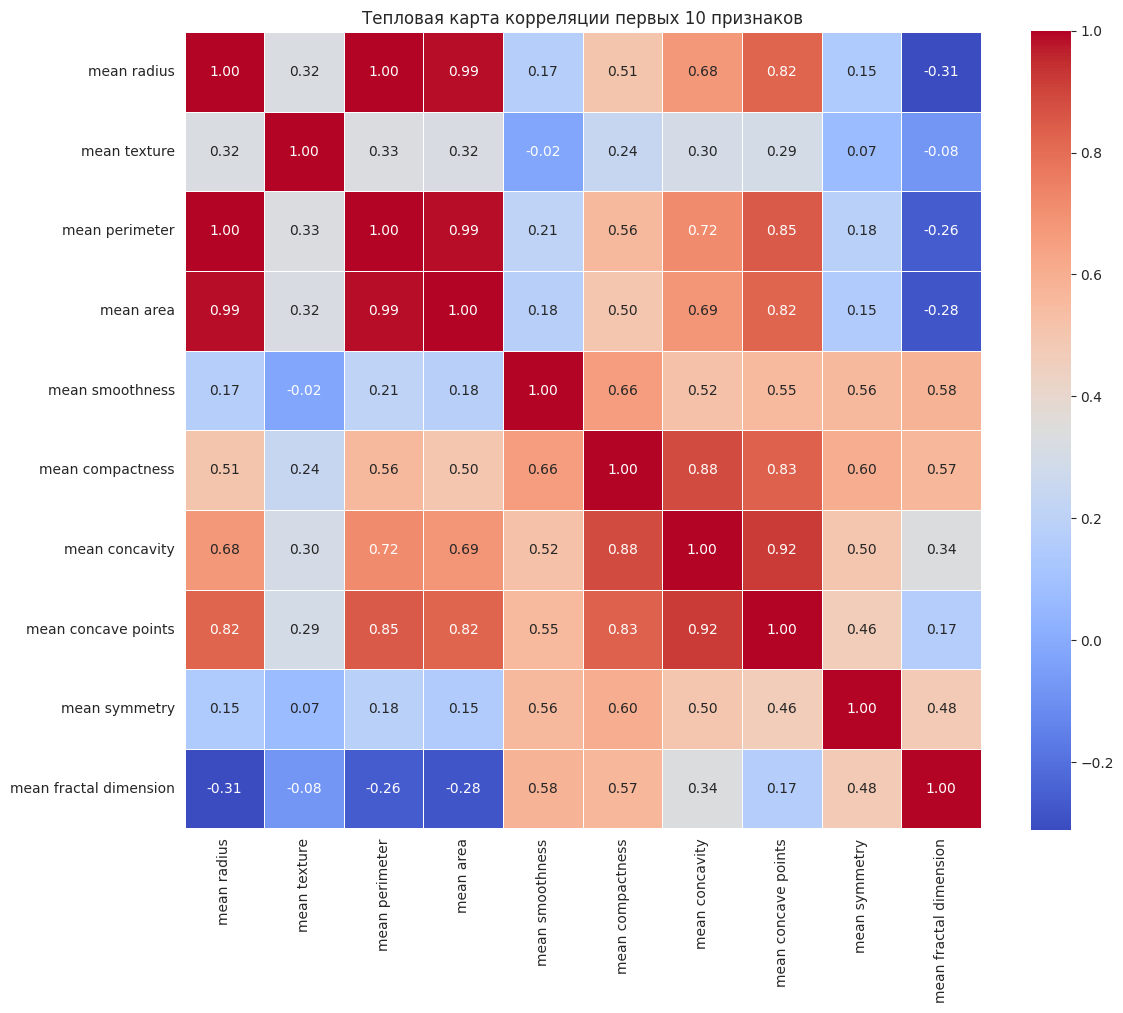

In [21]:
feature_subset = cancer.feature_names[:10]
corr_matrix = df[feature_subset].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            square=True,
            fmt='.2f',
            linewidths=0.5)
plt.title('Тепловая карта корреляции первых 10 признаков')
plt.tight_layout()
plt.show()


## Обучение модели

In [22]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)

svm_model.fit(X_train_scaled, y_train)

print("МОДЕЛЬ SVM:")
print(f"Ядро (kernel): {svm_model.kernel}")
print(f"Параметр C: {svm_model.C}")
print(f"Параметр gamma: {svm_model.gamma}")
print(f"Классы: {svm_model.classes_} ({cancer.target_names[0]}=0, {cancer.target_names[1]}=1)")

МОДЕЛЬ SVM:
Ядро (kernel): rbf
Параметр C: 1.0
Параметр gamma: scale
Классы: [0 1] (malignant=0, benign=1)


## Прогнозы модели

In [23]:
y_pred = svm_model.predict(X_test_scaled)
y_pred_proba = svm_model.predict_proba(X_test_scaled)

print("СРАВНЕНИЕ ПРЕДСКАЗАНИЙ (первые 15):")
print(f"{'№':3} {'Реальный':12} {'Предсказанный':12} {'Вероятность':15}")

for i in range(15):
    real = cancer.target_names[y_test[i]]
    pred = cancer.target_names[y_pred[i]]
    proba = y_pred_proba[i][y_pred[i]]
    print(f"{i+1:2} {real:12} {pred:12} {proba:.3f}")

СРАВНЕНИЕ ПРЕДСКАЗАНИЙ (первые 15):
№   Реальный     Предсказанный Вероятность    
 1 malignant    malignant    0.989
 2 benign       benign       0.950
 3 benign       benign       0.918
 4 malignant    malignant    0.970
 5 malignant    malignant    0.591
 6 malignant    malignant    0.997
 7 benign       benign       0.995
 8 malignant    malignant    0.999
 9 benign       benign       0.994
10 malignant    malignant    0.787
11 benign       benign       1.000
12 benign       benign       0.993
13 malignant    malignant    0.997
14 malignant    benign       0.846
15 benign       benign       1.000


## Графики выходных результатов


 ТОЧНОСТЬ МОДЕЛИ SVM: 0.9766 (97.66%)

 ОТЧЕТ ПО КЛАССИФИКАЦИИ:
              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        64
      benign       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



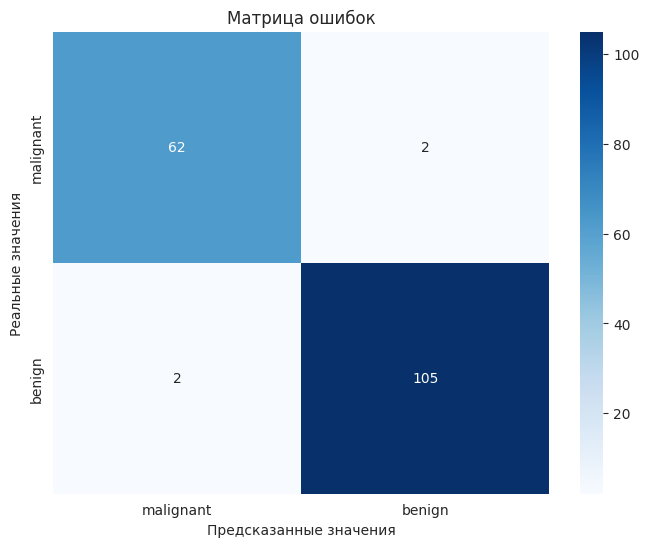

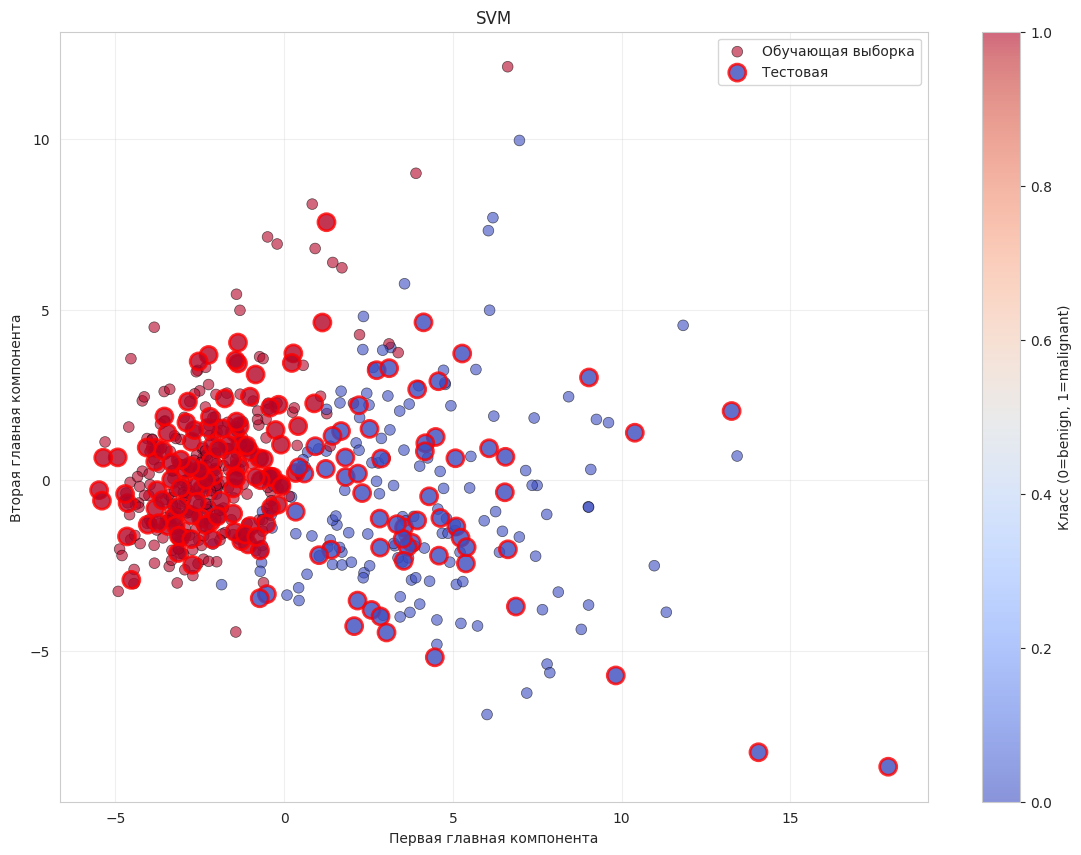

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n ТОЧНОСТЬ МОДЕЛИ SVM: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n ОТЧЕТ ПО КЛАССИФИКАЦИИ:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title(f'Матрица ошибок')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)
y_pred_pca = svm_pca.predict(X_test_pca)

plt.figure(figsize=(14, 10))
scatter_train = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                            c=y_train, cmap='coolwarm', alpha=0.6,
                            s=60, edgecolors='k', linewidth=0.5)

scatter_test = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                           c=y_pred_pca, cmap='coolwarm',
                           s=150, edgecolors='red', linewidth=2,
                           marker='o', alpha=0.8)

plt.title(f'SVM')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter_train, label='Класс (0=benign, 1=malignant)')
plt.legend(['Обучающая выборка', 'Тестовая'],
           loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()